# Modelo Perceptrón:

In [1]:
import numpy as np
import pandas as pd
from tensorflow import keras
import matplotlib.pyplot as plt
from tensorflow.keras import layers
from tensorflow.keras.layers import Dropout

## Cargamos los datos del autoencoder y el modelo:

In [2]:
X_train_latent = np.load("X_train_latent.npy", allow_pickle=True)
X_val_latent = np.load("X_val_latent.npy", allow_pickle=True)
y_train = np.load("y_train.npy", allow_pickle=True)
y_val = np.load("y_val.npy", allow_pickle=True)

In [3]:
print(X_train_latent.shape)
print(X_val_latent.shape)
print(y_train.shape)
print(y_val.shape)

(2934817, 32)
(733705, 32)
(2934817,)
(733705,)


## Definición del Perceptrón:

In [4]:
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
import numpy as np
from sklearn.model_selection import train_test_split

# CODIFICACIÓN DE ETIQUETAS: convertimos los strings a números
label_encoder = LabelEncoder()
y_train_labels = label_encoder.fit_transform(y_train) 
y_val_labels = label_encoder.transform(y_val)

X_val_final, X_test, y_val_labels_split, y_test_labels = train_test_split(
    X_val_latent, y_val_labels,
    test_size=0.5, 
    random_state=42, 
    stratify=y_val_labels  # Mantiene el balance de las 5 clases
)

# Ahora convertir a one-hot (para el entrenamiento)
y_train_one_hot = to_categorical(y_train_labels, num_classes=5)
y_val_one_hot = to_categorical(y_val_labels_split, num_classes=5)
y_test_one_hot = to_categorical(y_test_labels, num_classes=5)


# CALCULAR PESOS DE CLASE
raw_weights = compute_class_weight('balanced', 
                                   classes=np.unique(y_train_labels),
                                   y=y_train_labels)

# Aplicamos raíz cuadrada para suavizar la escala
class_weights_smoothed = np.sqrt(raw_weights)

# Creamos el diccionario con los pesos suavizados
class_weight_dict = dict(enumerate(class_weights_smoothed))

print("Pesos de clase calculados:")
# label_encoder.classes_ contiene los nombres originales en el orden correcto (0 a 4)
for i, clase in enumerate(label_encoder.classes_):
    print(f"  {clase}: {class_weight_dict[i]:.4f}")

Pesos de clase calculados:
  DDoS: 0.6172
  DoS: 0.6668
  Normal: 39.5104
  Reconnaissance: 2.8339
  Theft: 93.5983


In [5]:
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.layers import Dropout

def modelo_perceptron(hp):
    
    # Input
    input_shape = (X_train_latent.shape[1],)
    
    # Hiperparámetros
    tasa_aprendizaje = hp.Choice('learning_rate', [5e-4, 1e-4, 5e-5])
    units1 = hp.Int('units1', 32, 128, step=32)
    units2 = hp.Int('units2', 32, 128, step=32)
    
    # Modelo
    model = keras.Sequential([
        layers.Input(shape=input_shape),
        layers.Dense(units1, activation='relu'),
        Dropout(0.3),
        layers.Dense(units2, activation='relu'),
        Dropout(0.3),
        layers.Dense(5, activation='softmax')
    ])
    
    # Compilación
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=tasa_aprendizaje, clipnorm=1.0),
        loss='categorical_crossentropy',
        metrics=['accuracy', keras.metrics.AUC(multi_label=True, name='auc')]
    )
    
    return model

El clipnorm es una técnica de clipping de gradientes que actúa como un "limitador de velocidad" o una válvula de seguridad para las actualizaciones del modelo.

In [7]:
import keras_tuner as kt

tuner = kt.RandomSearch(
    modelo_perceptron,
    objective='val_auc',
    max_trials=10,
    directory='C:/Users/Usuario/keras_tuner_runs',
    project_name='mlp_classifier',
    seed=42
)

history = tuner.search(
    X_train_latent,
    y_train_one_hot,
    validation_data=(X_val_final, y_val_one_hot),
    epochs=20,
    batch_size=1024,
    class_weight=class_weight_dict,
    verbose=1,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=10,
            restore_best_weights=True
        )
    ]
)


Trial 10 Complete [00h 07m 30s]
val_auc: 0.9998956918716431

Best val_auc So Far: 0.9999696016311646
Total elapsed time: 01h 11m 26s


In [8]:
# Obtención del mejor modelo
best_model = tuner.get_best_models(num_models=1)[0]

# Guardarlo en el formato nativo de Keras
best_model.save('mejor_modelo_clasificador.keras')

# Obtención de los mejores hiperparámetros 
print("\nMejores hiperparámetros:")
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print(best_hps.values)


# Evaluación final con el conjunto de TEST
test_loss, test_acc, test_auc = best_model.evaluate(X_test, y_test_one_hot)
print(f"Resultado final en TEST - Accuracy: {test_acc:.4f}, AUC: {test_auc:.4f}")

c:\Users\Usuario\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\saving\saving_lib.py:801: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))



Mejores hiperparámetros:
{'learning_rate': 0.0005, 'units1': 128, 'units2': 96}
11465/11465 ━━━━━━━━━━━━━━━━━━━━ 19s 2ms/step - accuracy: 0.9987 - auc: 0.9833 - loss: 0.0042
Resultado final en TEST - Accuracy: 0.9987, AUC: 0.9833


11465/11465 ━━━━━━━━━━━━━━━━━━━━ 14s 1ms/step


<Figure size 1000x800 with 0 Axes>

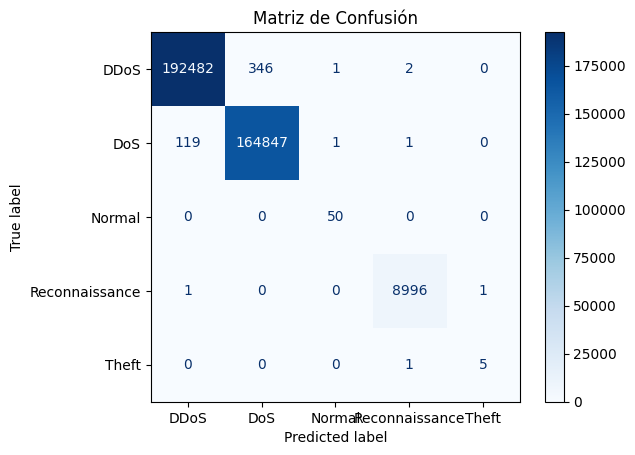

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# Obtener las etiquetas reales en formato numérico (0 a 4)
y_test_true = np.argmax(y_test_one_hot, axis=1) #ç

# Obtener las predicciones del modelo (probabilidades)
y_pred_probs = best_model.predict(X_test)

# Convertir probabilidades en la clase con mayor valor
y_pred_labels = np.argmax(y_pred_probs, axis=1)

# Matriz de confusión
cm = confusion_matrix(y_test_true, y_pred_labels)

# Visualización
plt.figure(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot(cmap='Blues', values_format='d')
plt.title("Matriz de Confusión")
plt.show()

In [10]:
# Reporte detallado por clase
print("\nReporte de Clasificación Detallado:")
print(classification_report(y_test_true, y_pred_labels, target_names=label_encoder.classes_))


Reporte de Clasificación Detallado:
                precision    recall  f1-score   support

          DDoS       1.00      1.00      1.00    192831
           DoS       1.00      1.00      1.00    164968
        Normal       0.96      1.00      0.98        50
Reconnaissance       1.00      1.00      1.00      8998
         Theft       0.83      0.83      0.83         6

      accuracy                           1.00    366853
     macro avg       0.96      0.97      0.96    366853
  weighted avg       1.00      1.00      1.00    366853

